In [77]:
#!pip install numpy pandas yfinance matplotlib scikit-learn xgboost

In [ ]:
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import f1_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_curve, auc, confusion_matrix, ConfusionMatrixDisplay
from sklearn.inspection import permutation_importance
from xgboost import XGBClassifier

In [79]:
# Config
TICKERS = ["CNQ.TO"]  ## can be multiple tickers

START_DATE = "2000-01-01"
END_DATE = "2024-12-31"
PRICE_FREQUENCY = "D"  # "D"|"W"|"ME"

N_FOLDS = 5
EMBARGO_DAYS = 5
TRANSACTION_COST_BPS = 10

VOLATILITY_WINDOW = 20  # window to calculate current volatility
VOLATILITY_THRESHOLD = 120  # window to calculate threshold

***
# Data

In [80]:
# Data
def get_prices(
    tickers: list[str], start: str, end: str, frequency: str = "D"
) -> pd.DataFrame:
    # TODO: explore different frequency, will need refactor
    raw = yf.download(tickers, start=start, end=end, auto_adjust=True)["Close"]
    if frequency == "D":
        return raw.dropna()
    return raw.resample(frequency).last().dropna()

In [81]:
# Features
def build_features(prices: pd.DataFrame) -> pd.DataFrame:
    features = pd.DataFrame(index=prices.index)
    features = _add_volatility_features(features, prices)
    features = _add_directional_features(features, prices)
    return features.dropna()


def _add_volatility_features(
    features: pd.DataFrame, prices: pd.DataFrame
) -> pd.DataFrame:
    # TODO: add features (GARCH?)
    # TODO: test features contributions
    # TODO: detect colinearity between features
    avg = prices.mean(axis=1)
    daily_return = np.log(avg / avg.shift(1))

    features["ret_t1"] = daily_return.shift(1)
    features["ret_t5"] = daily_return.rolling(5).sum().shift(1)
    features["ret_t20"] = daily_return.rolling(20).sum().shift(1)
    features["vol_20d"] = daily_return.rolling(20).std().shift(1)
    features["rsi_14"] = _compute_rsi(avg).shift(1)
    return features


def _add_directional_features(
    features: pd.DataFrame, prices: pd.DataFrame
) -> pd.DataFrame:
    # TODO: Add Step 2 specific features
    return features


def _compute_rsi(prices: pd.Series, period: int = 14) -> pd.Series:
    delta = prices.diff()
    gain = delta.clip(lower=0).rolling(period).mean()
    loss = (-delta.clip(upper=0)).rolling(period).mean()
    return 100 - (100 / (1 + gain / loss))

In [ ]:
# Feature importance
def compute_mda(model, X_test: pd.DataFrame, y_test: pd.Series, scoring="neg_log_loss", n_repeats: int = 10) -> pd.Series:
    if scoring not in ["neg_log_lss", "accuracy", "f1"]:
        raise Exception("Wrong scoring method.")
    result = permutation_importance(model, X_test, y_test, scoring=scoring, n_repeats=n_repeats, random_state=42)
    return pd.Series(result.importances_mean, index=X_test.columns)

In [83]:
# Labels
def build_volatility_labels(prices: pd.DataFrame) -> pd.Series:
    """
    Determine if tomorrow will be volatile using sliding window
    1 = realized vol tomorrow exceeds the 120-day rolling median
    0 = normal regime
    """
    avg = prices.mean(axis=1)
    daily_return = np.log(avg / avg.shift(1))
    realized_vol = daily_return.rolling(VOLATILITY_WINDOW).std()
    threshold = realized_vol.rolling(VOLATILITY_THRESHOLD).median()

    return (realized_vol.shift(-1) > threshold).astype(int)


def build_direction_labels(prices: pd.DataFrame) -> pd.Series:
    """
    1 = sector up tomorrow, 0 = sector down.
    """
    avg = prices.mean(axis=1)
    fwd_ret = avg.shift(-1) / avg - 1
    return (fwd_ret > 0).astype(int)

In [84]:
# Data set
def build_dataset(prices: pd.DataFrame) -> tuple[pd.DataFrame, pd.Series, pd.Series]:
    """
    Concatened all tickers
    """
    all_X, all_y_vol, all_y_dir = {}, {}, {}

    for ticker in prices.columns:
        ticker_prices = prices[[ticker]]

        X = build_features(ticker_prices)
        y_vol = build_volatility_labels(ticker_prices)
        y_dir = build_direction_labels(ticker_prices)

        common = X.index.intersection(y_vol.index).intersection(y_dir.index)
        all_X[ticker] = X.loc[common]
        all_y_vol[ticker] = y_vol.loc[common]
        all_y_dir[ticker] = y_dir.loc[common]

        X_out = pd.concat(all_X)
        y_vol_out = pd.concat(all_y_vol)
        y_dir_out = pd.concat(all_y_dir)

        X_out.index.names = ["ticker", "date"]
        y_vol_out.index.names = ["ticker", "date"]
        y_dir_out.index.names = ["ticker", "date"]

    return X_out, y_vol_out, y_dir_out

In [85]:
def walk_forward_splits_by_date(
    index: pd.MultiIndex, n_folds: int, embargo: int
) -> list:
    """
    Walk-forward splits by date (López de Prado, 2018, ch. 7).
    Each fold is split by date + embargo to ensure no data leakage
    """
    dates = sorted(index.get_level_values("date").unique())
    n = len(dates)
    fold_size = n // (n_folds + 1)
    splits = []

    for k in range(1, n_folds + 1):
        train_end = dates[k * fold_size]
        test_start = dates[min(k * fold_size + embargo, n - 1)]
        test_end = dates[min((k + 1) * fold_size, n - 1)]

        train_mask = index.get_level_values("date") <= train_end
        test_mask = (index.get_level_values("date") > test_start) & (
            index.get_level_values("date") <= test_end
        )

        splits.append((train_mask, test_mask))

    return splits

***
# Models

In [ ]:
# Model 1 - Volatility
def train_volatility_model(
    X_train: pd.DataFrame, y_train: pd.Series
) -> LogisticRegression:
    # TODO: Try different models
    model = LogisticRegression(class_weight="balanced", max_iter=500, random_state=42)
    model.fit(X_train, y_train)
    return model


def predict_volatility_model(model, X: pd.DataFrame) -> pd.Series:
    return pd.Series(model.predict(X), index=X.index)

In [87]:
# Model 2 - Direction
def train_directional_model(X_train: pd.DataFrame, y_train: pd.Series) -> XGBClassifier:
    model = XGBClassifier(
        n_estimators=200,
        max_depth=4,
        learning_rate=0.05,
        random_state=42,
        eval_metric="logloss",
        verbosity=0,
    )
    model.fit(X_train, y_train)
    return model


def predict_directional_model(model, X: pd.DataFrame) -> pd.Series:
    return pd.Series(model.predict(X), index=X.index)

***
# Plot

In [88]:
def plot_mda(mda_m1: pd.DataFrame, mda_m2: pd.DataFrame) -> None:
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    fig.suptitle("MDA - Mean Decrease Accuracy (average across folds)", fontsize=14)

    for ax, mda, title in [
        (axes[0], mda_m1, "M1 — Volatility model"),
        (axes[1], mda_m2, "M2 — Direction model"),
    ]:
        if mda.empty:
            ax.set_title(f"{title}\n(no data)")
            ax.axis("off")
            continue

        means = mda.mean().sort_values(ascending=True)
        stds = mda.std().reindex(means.index)

        ax.barh(means.index, means.values, xerr=stds.values, capsize=4, color="steelblue", alpha=0.8)
        ax.axvline(0, color="black", linewidth=0.8, linestyle="--")
        ax.set_title(title)
        ax.set_xlabel("Mean decrease in F1")

    plt.tight_layout()
    plt.show()

In [89]:
def display_results(
    all_X: pd.DataFrame, all_signals: pd.DataFrame, step1_f1s: list, step2_f1s: list
) -> None:
    print(f"\n----- Dataset -----")
    print(
        f"Dataset: {len(all_X)} lignes, {all_X.index.get_level_values('ticker').nunique()} tickers"
    )
    print(all_X.describe())

    print(f"\----- Aggregate metrics -----")
    print(f"  Step 1 (Volatility) avg F1:  {np.mean(step1_f1s):.3f}")
    print(f"  Step 2 (Direction)  avg F1:  {np.mean(step2_f1s):.3f}")

    valid_signals = all_signals.dropna()
    print(f"  Signal coverage: {valid_signals.mean():.1%} of days in market")

    print("------------------------------")

In [90]:
def plot_metrics(
    y_true_vol: pd.Series,
    y_pred_vol: pd.Series,
    y_true_dir: pd.Series,
    y_pred_dir: pd.Series,
    vol_alert: pd.Series,
) -> None:
    fig, axes = plt.subplots(2, 2, figsize=(12, 10))
    fig.suptitle("Model Evaluation Metrics", fontsize=14)

    # ── M1 ROC Curve ──────────────────────────────────────────────────────────
    fpr, tpr, _ = roc_curve(y_true_vol, y_pred_vol)
    roc_auc = auc(fpr, tpr)
    axes[0, 0].plot(fpr, tpr, color="steelblue", label=f"AUC = {roc_auc:.3f}")
    axes[0, 0].plot([0, 1], [0, 1], color="gray", linestyle="--", label="Random")
    axes[0, 0].set_title("M1 — Volatility ROC Curve")
    axes[0, 0].set_xlabel("False Positive Rate")
    axes[0, 0].set_ylabel("True Positive Rate")
    axes[0, 0].legend()

    # ── M1 Confusion Matrix ───────────────────────────────────────────────────
    cm_vol = confusion_matrix(y_true_vol, y_pred_vol)
    ConfusionMatrixDisplay(cm_vol, display_labels=["Low Vol", "High Vol"]).plot(
        ax=axes[0, 1], colorbar=False, cmap="Blues"
    )
    axes[0, 1].set_title("M1 — Volatility Confusion Matrix")

    # ── M2 ROC Curve (on alerted days only) ───────────────────────────────────
    y_true_dir_alerted = y_true_dir[vol_alert]
    y_pred_dir_alerted = y_pred_dir[vol_alert]
    fpr, tpr, _ = roc_curve(y_true_dir_alerted, y_pred_dir_alerted)
    roc_auc = auc(fpr, tpr)
    axes[1, 0].plot(fpr, tpr, color="steelblue", label=f"AUC = {roc_auc:.3f}")
    axes[1, 0].plot([0, 1], [0, 1], color="gray", linestyle="--", label="Random")
    axes[1, 0].set_title("M2 — Direction ROC Curve (alerted days only)")
    axes[1, 0].set_xlabel("False Positive Rate")
    axes[1, 0].set_ylabel("True Positive Rate")
    axes[1, 0].legend()

    # ── M2 Confusion Matrix (on alerted days only) ────────────────────────────
    cm_dir = confusion_matrix(y_true_dir_alerted, y_pred_dir_alerted)
    ConfusionMatrixDisplay(cm_dir, display_labels=["Down", "Up"]).plot(
        ax=axes[1, 1], colorbar=False, cmap="Blues"
    )
    axes[1, 1].set_title("M2 — Direction Confusion Matrix (alerted days only)")

    plt.tight_layout()
    plt.show()

***
# Pipeline

In [ ]:
# Pipeline
def run():
    print("----- Loading data -----")
    prices = get_prices(TICKERS, START_DATE, END_DATE, PRICE_FREQUENCY)
    print(f"  {len(prices)} trading days × {len(prices.columns)} tickers")

    all_X, all_y_vol, all_y_dir = build_dataset(prices)
    splits = list(
        walk_forward_splits_by_date(all_X.index, n_folds=N_FOLDS, embargo=EMBARGO_DAYS)
    )

    print(f"\n----- Walk-forward: {len(splits)} folds -----")

    # Storage for OOS signals
    all_vol_preds = pd.Series(index=all_X.index, dtype=float)
    all_dir_preds = pd.Series(index=all_X.index, dtype=float)
    all_signals = pd.Series(index=all_X.index, dtype=float)

    step1_f1s, step2_f1s = [], []
    mda_m1_folds, mda_m2_folds = [], []

    # ----- Walk forward loop -----
    for fold_idx, (train_mask, test_mask) in enumerate(splits):
        X_train, X_test = all_X[train_mask], all_X[test_mask]
        y_vol_train, y_vol_test = all_y_vol[train_mask], all_y_vol[test_mask]
        y_dir_train, y_dir_test = all_y_dir[train_mask], all_y_dir[test_mask]

        # Scale features — fit on train only to avoid leakage
        scaler = StandardScaler()
        X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), index=X_train.index, columns=X_train.columns)
        X_test_scaled = pd.DataFrame(scaler.transform(X_test), index=X_test.index, columns=X_test.columns)

        # Step 1: train volatility model on full training set
        vol_model = train_volatility_model(X_train_scaled, y_vol_train)
        vol_pred_test = predict_volatility_model(vol_model, X_test_scaled)
        all_vol_preds[test_mask] = vol_pred_test.values

        vol_f1 = f1_score(y_vol_test, vol_pred_test, zero_division=0)
        step1_f1s.append(vol_f1)

        # MDA model 1
        mda_m1_folds.append(compute_mda(vol_model, X_test_scaled, y_vol_test, "f1"))

        # Step 2: train ONLY on high-volatility training observations
        high_vol_mask = y_vol_train == 1
        X_train_filtered = X_train_scaled[high_vol_mask]
        y_dir_train_filtered = y_dir_train[high_vol_mask]

        if len(X_train_filtered) < 30:
            print(
                f"  Fold {fold_idx+1}: not enough high-vol training samples, skipping."
            )
            continue

        directional_model = train_directional_model(
            X_train_filtered, y_dir_train_filtered
        )

        # Generate signals: only predict direction when vol alert is active
        vol_alert_test = vol_pred_test == 1
        dir_pred_test = pd.Series(0, index=X_test.index)

        if vol_alert_test.sum() > 0:
            dir_pred_on_alert = predict_directional_model(
                directional_model, X_test_scaled[vol_alert_test]
            )
            dir_pred_test[vol_alert_test] = dir_pred_on_alert.values

            # MDA model 2
            mda_m2_folds.append(compute_mda(directional_model, X_test_scaled[vol_alert_test], y_dir_test[vol_alert_test], "f1"))

        all_dir_preds[test_mask] = dir_pred_test.values

        # Final signal = 1 only if vol alert AND direction = up
        signal_test = (vol_pred_test == 1) & (dir_pred_test == 1)
        all_signals[test_mask] = signal_test.astype(int).values

        # Metrics Step 2 — evaluate only on alerted observations
        dir_f1 = 0.0
        if vol_alert_test.sum() > 0:
            dir_f1 = f1_score(
                y_dir_test[vol_alert_test],
                dir_pred_test[vol_alert_test],
                zero_division=0,
            )
            step2_f1s.append(dir_f1)

        print(
            f"  Fold {fold_idx+1}:  Step1 F1={vol_f1:.3f}  |  "
            f"Vol alerts={vol_alert_test.sum()}/{len(vol_alert_test)}  |  "
            f"Model 2 F1={dir_f1:.3f}"
        )

    # ----- Results -----
    display_results(all_X, all_signals, step1_f1s, step2_f1s)

    valid_preds = all_vol_preds.dropna().index
    vol_alert_oos = all_vol_preds.loc[valid_preds] == 1

    plot_metrics(
        y_true_vol=all_y_vol.loc[valid_preds],
        y_pred_vol=all_vol_preds.loc[valid_preds],
        y_true_dir=all_y_dir.loc[valid_preds],
        y_pred_dir=all_dir_preds.loc[valid_preds].fillna(0).astype(int),
        vol_alert=vol_alert_oos,
    )

    # ----- MDA -----
    plot_mda(pd.DataFrame(mda_m1_folds), pd.DataFrame(mda_m2_folds))

    # ----- Backtest -----
    # TODO
    return

[*********************100%***********************]  1 of 1 completed

----- Loading data -----
  6278 trading days × 1 tickers

----- Walk-forward: 5 folds -----


  Fold 1:  Step1 F1=0.787  |  Vol alerts=599/1037  |  Model 2 F1=0.532
  Fold 2:  Step1 F1=0.624  |  Vol alerts=665/1037  |  Model 2 F1=0.593
  Fold 3:  Step1 F1=0.617  |  Vol alerts=321/1037  |  Model 2 F1=0.535
  Fold 4:  Step1 F1=0.625  |  Vol alerts=404/1037  |  Model 2 F1=0.522
  Fold 5:  Step1 F1=0.617  |  Vol alerts=331/1037  |  Model 2 F1=0.571

----- Dataset -----
Dataset: 6257 lignes, 1 tickers
            ret_t1       ret_t5      ret_t20      vol_20d       rsi_14
count  6257.000000  6257.000000  6257.000000  6257.000000  6257.000000
mean      0.000581     0.002847     0.011492     0.021201    52.394691
std       0.024361     0.055452     0.106390     0.012102    16.762581
min      -0.345035    -0.635133    -1.300934     0.006958     2.668357
25%      -0.011569    -0.024919    -0.047419     0.014876    40.106889
50%       0.000755     0.003790     0.014909     0.018561    52.292517
75%       0.012739     0.033496     0.073216     0.023922    64.564744
max       0.203858     0

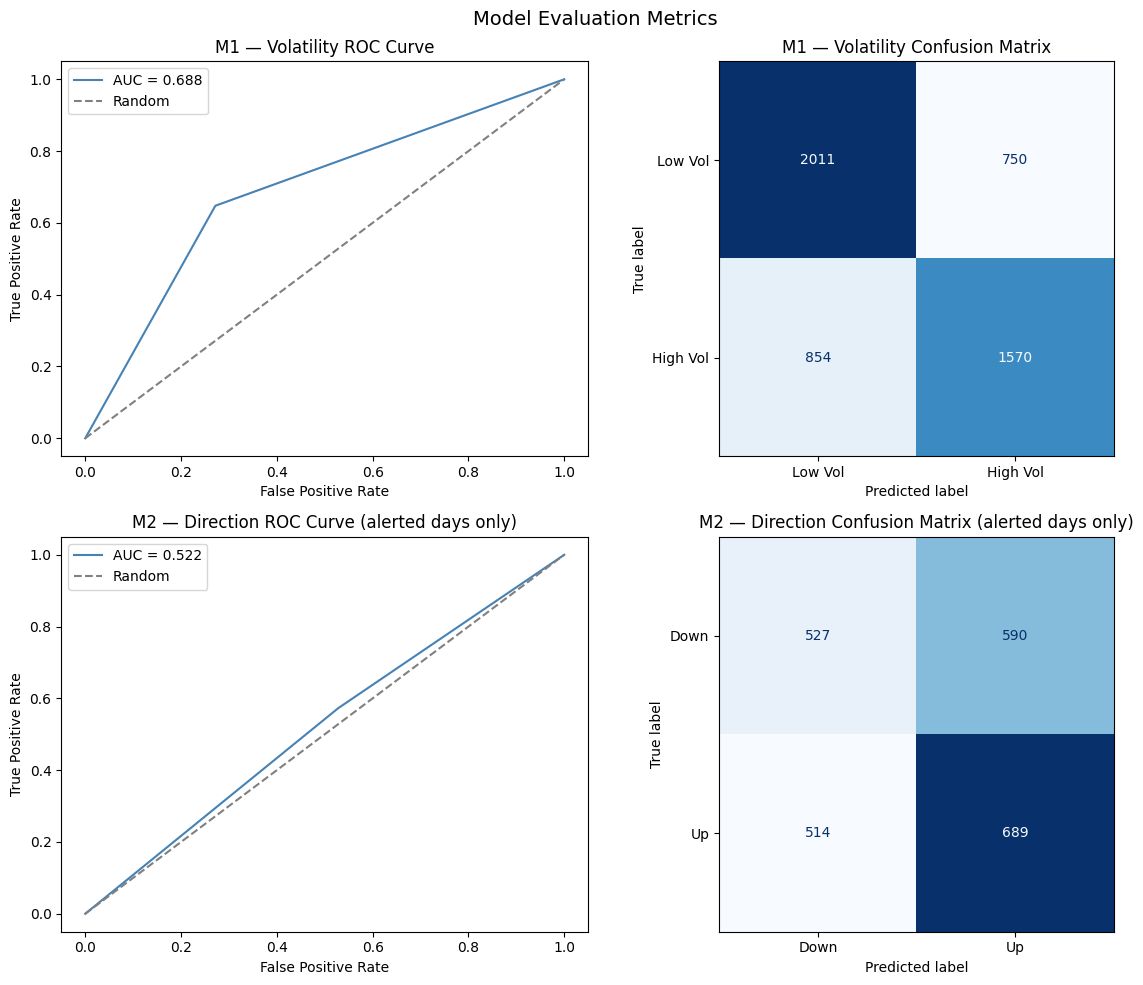

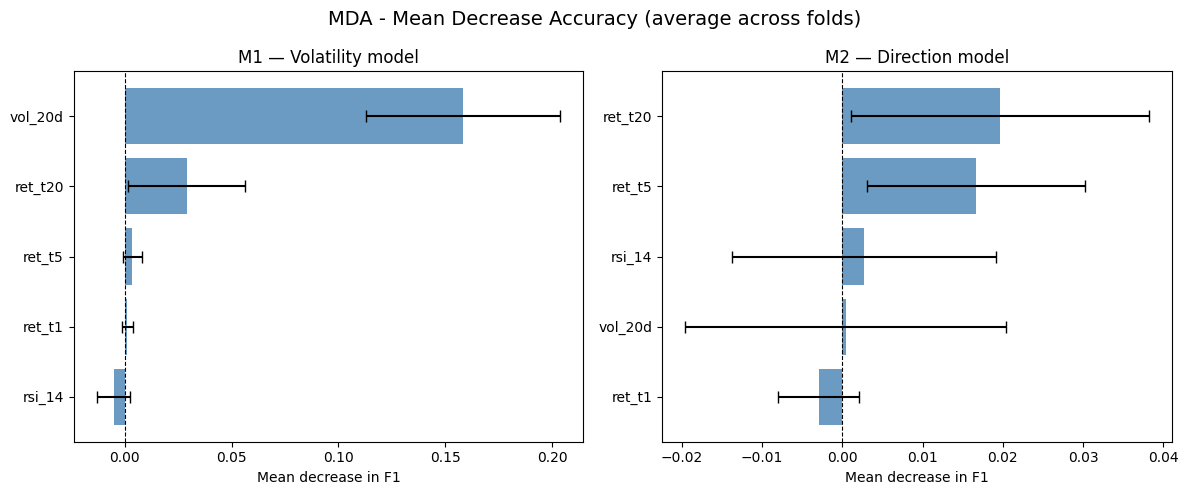

In [92]:
run()